In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

Matplotlib is building the font cache; this may take a moment.


In [6]:
df = pd.read_csv("../data/processed/ecommerce_master_dataset.csv")

In [7]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "review_creation_date",
    "review_answer_timestamp"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  str           
 1   customer_id                    119143 non-null  str           
 2   order_status                   119143 non-null  str           
 3   order_purchase_timestamp       119143 non-null  datetime64[us]
 4   order_approved_at              118966 non-null  datetime64[us]
 5   order_delivered_carrier_date   117057 non-null  datetime64[us]
 6   order_delivered_customer_date  115722 non-null  datetime64[us]
 7   order_estimated_delivery_date  119143 non-null  datetime64[us]
 8   delivery_days                  115722 non-null  float64       
 9   approval_time_hours            118966 non-null  float64       
 10  delivery_delay_days            115722 non-null  float64       
 11  order_month

# Exploratory Data Analysis

## Objective

Analyze customer purchasing behavior,
sales performance,
delivery performance,
payment trends,
and customer satisfaction.

In [9]:
monthly_orders = (
    df.groupby("order_month")
      .size()
      .reset_index(name="Total Orders")
)

monthly_orders

,order_month,Total Orders
0,2016-09,7
1,2016-10,401
2,2016-12,1
3,2017-01,1035
4,2017-02,2123
5,2017-03,3243
6,2017-04,2878
7,2017-05,4485
8,2017-06,3853
9,2017-07,4949


In [10]:
df["delivery_days"].describe()

count    115722.000000
mean         12.022589
std           9.454922
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

In [11]:
df["review_score"].value_counts().sort_index()

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64

In [12]:
df["payment_type"].value_counts()

payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: count, dtype: int64

In [13]:
df["order_status"].value_counts()

order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64

In [14]:
df["product_category_name"].value_counts().head(20)

product_category_name
cama_mesa_banho                11988
beleza_saude                   10032
esporte_lazer                   9004
moveis_decoracao                8832
informatica_acessorios          8150
utilidades_domesticas           7380
relogios_presentes              6213
telefonia                       4726
ferramentas_jardim              4590
automotivo                      4400
brinquedos                      4281
cool_stuff                      3999
perfumaria                      3589
bebes                           3204
eletronicos                     2846
papelaria                       2625
fashion_bolsas_e_acessorios     2170
pet_shop                        2030
moveis_escritorio               1788
consoles_games                  1192
Name: count, dtype: int64

In [15]:
df["customer_state"].value_counts()

customer_state
SP    50265
RJ    15518
MG    13819
RS     6573
PR     6043
SC     4345
BA     4091
DF     2516
GO     2466
ES     2360
PE     1906
CE     1565
MT     1132
PA     1129
MS      862
MA      856
PB      644
PI      576
RN      574
AL      464
SE      403
TO      340
RO      292
AM      173
AC       95
AP       84
RR       52
Name: count, dtype: int64

In [16]:
df["purchase_weekday"].value_counts()

purchase_weekday
Monday       19366
Tuesday      19315
Wednesday    18640
Thursday     17826
Friday       17006
Sunday       14096
Saturday     12894
Name: count, dtype: int64

In [17]:
df["delivery_delay_days"].describe()

count    115722.000000
mean        -12.048392
std          10.163801
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_delay_days, dtype: float64

# Dataset Overview

## Objective

Understand the structure and quality of the integrated e-commerce dataset before performing business analysis.

In [18]:
df.shape


(119143, 42)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  str           
 1   customer_id                    119143 non-null  str           
 2   order_status                   119143 non-null  str           
 3   order_purchase_timestamp       119143 non-null  datetime64[us]
 4   order_approved_at              118966 non-null  datetime64[us]
 5   order_delivered_carrier_date   117057 non-null  datetime64[us]
 6   order_delivered_customer_date  115722 non-null  datetime64[us]
 7   order_estimated_delivery_date  119143 non-null  datetime64[us]
 8   delivery_days                  115722 non-null  float64       
 9   approval_time_hours            118966 non-null  float64       
 10  delivery_delay_days            115722 non-null  float64       
 11  order_month

In [20]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,approval_time_hours,delivery_delay_days,order_month,order_year,purchase_weekday,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0.178333,-8.0,2017-10,2017,Monday,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0.178333,-8.0,2017-10,2017,Monday,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0.178333,-8.0,2017-10,2017,Monday,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,30.713889,-6.0,2018-07,2018,Tuesday,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,0.276111,-18.0,2018-08,2018,Wednesday,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18,2018-08-22 19:07:58


# Business Question 1

How has the number of orders changed over time?

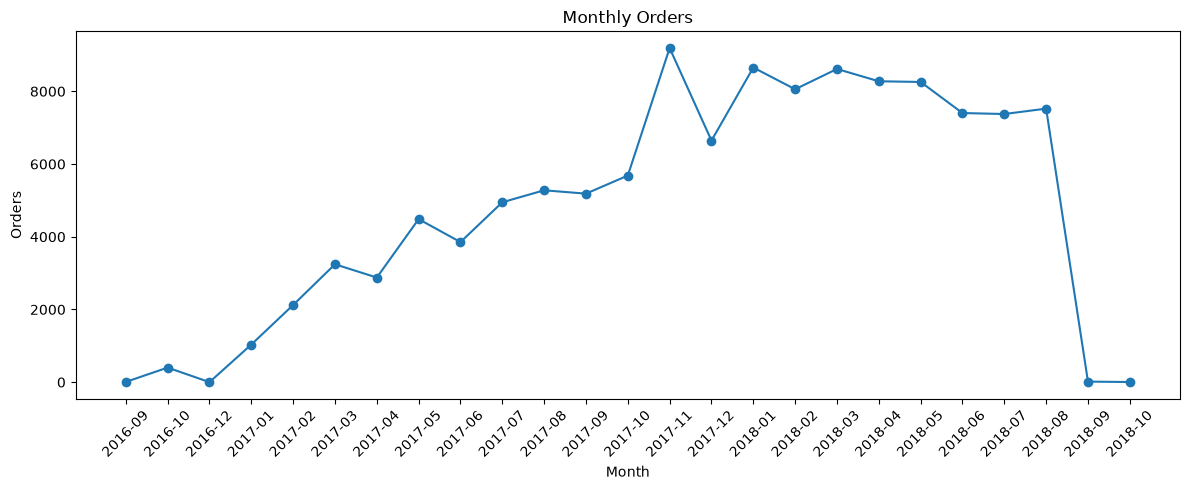

In [21]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_orders["order_month"],
    monthly_orders["Total Orders"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Orders")

plt.xlabel("Month")

plt.ylabel("Orders")

plt.tight_layout()

plt.show()

# Business Question 2

What is the distribution of order statuses?

In [22]:
order_status = (
    df["order_status"]
      .value_counts()
)

order_status

order_status
delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: count, dtype: int64

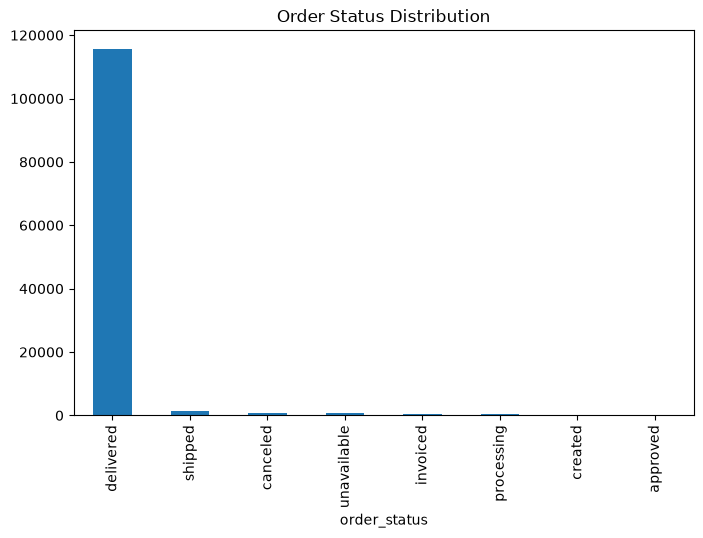

In [23]:
order_status.plot(kind="bar", figsize=(8,5))

plt.title("Order Status Distribution")

plt.show()

In [24]:
review_scores = (
    df["review_score"]
      .value_counts()
      .sort_index()
)

review_scores

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64

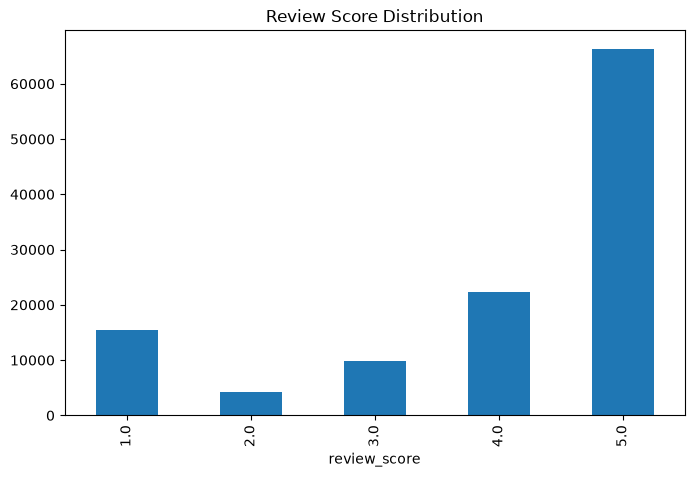

In [25]:
review_scores.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Review Score Distribution")

plt.show()

In [26]:
payment = (
    df["payment_type"]
      .value_counts()
)

payment

payment_type
credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: count, dtype: int64

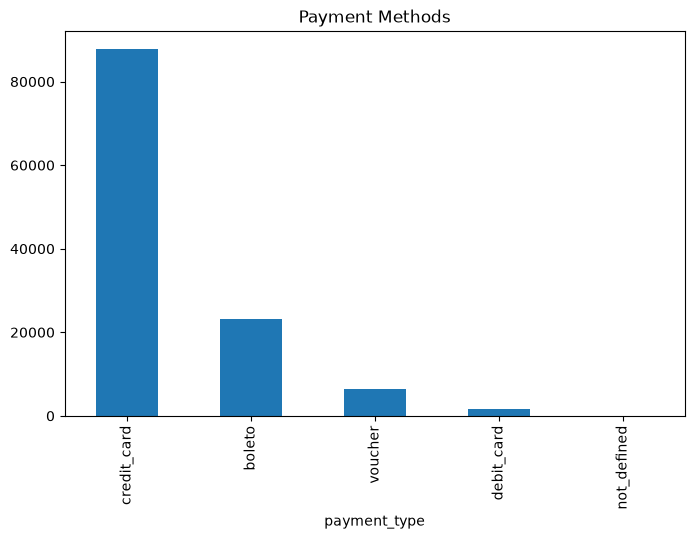

In [27]:
payment.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Payment Methods")

plt.show()

In [28]:
states = (
    df["customer_state"]
      .value_counts()
      .head(10)
)

states

customer_state
SP    50265
RJ    15518
MG    13819
RS     6573
PR     6043
SC     4345
BA     4091
DF     2516
GO     2466
ES     2360
Name: count, dtype: int64

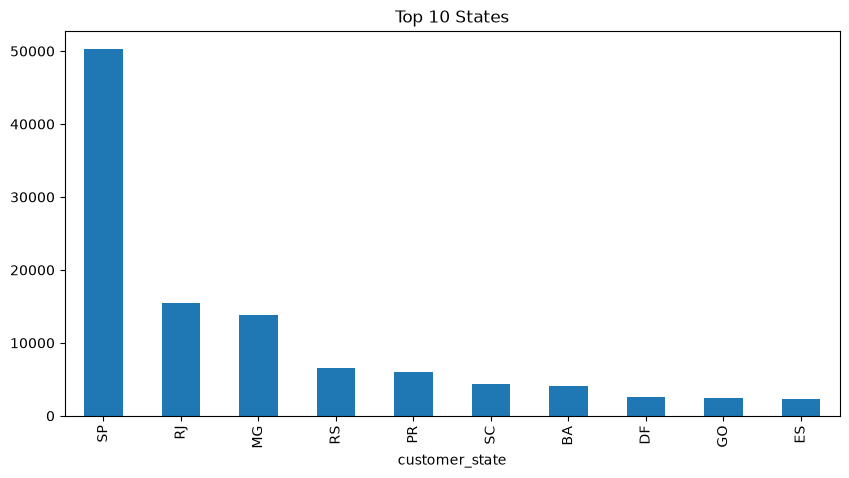

In [29]:
states.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 States")

plt.show()

In [30]:
df["delivery_days"].describe()

count    115722.000000
mean         12.022589
std           9.454922
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

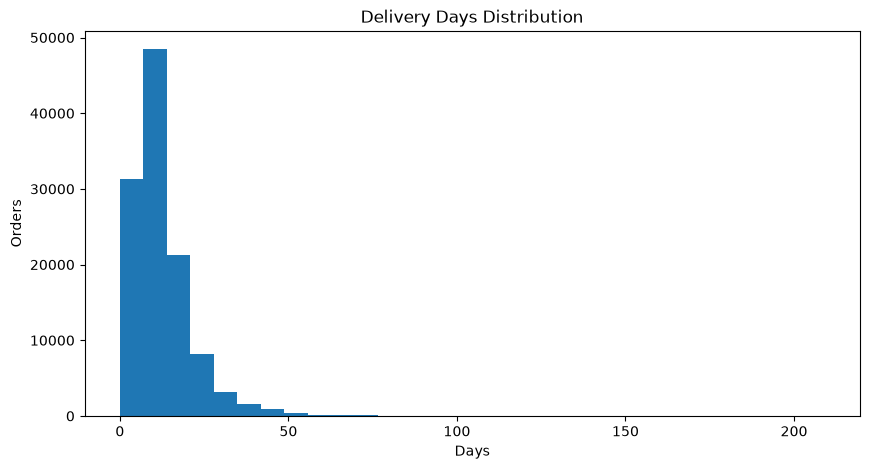

In [31]:
plt.figure(figsize=(10,5))

plt.hist(
    df["delivery_days"].dropna(),
    bins=30
)

plt.title("Delivery Days Distribution")

plt.xlabel("Days")

plt.ylabel("Orders")

plt.show()

In [32]:
weekday = (
    df["purchase_weekday"]
      .value_counts()
)

weekday

purchase_weekday
Monday       19366
Tuesday      19315
Wednesday    18640
Thursday     17826
Friday       17006
Sunday       14096
Saturday     12894
Name: count, dtype: int64

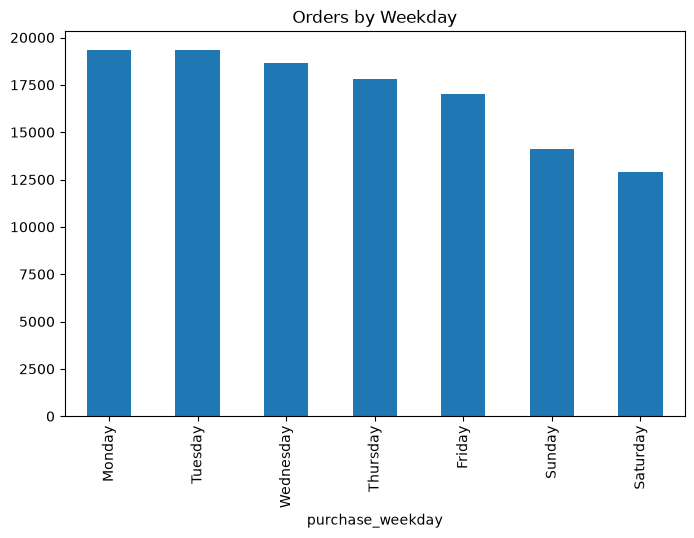

In [33]:
weekday.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Orders by Weekday")

plt.show()

### Observation

Most orders were placed in November 2017.

### Business Insight

Demand increased significantly during the holiday shopping season.

### Recommendation

Increase inventory and marketing campaigns before peak months.